In [1]:
# ============================================
# GPU Setup Verification
# ============================================

import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
2
Tesla T4


In [2]:
# ============================================
# Set Computation Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/maryland434/customer-support/customer_support_tickets.csv


In [5]:
# ============================================
# Load Customer Support Ticket Dataset
# ============================================

import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/maryland434/customer-support/customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,3/22/2021,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,6/1/2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,5/22/2021,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,6/1/2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,7/14/2020,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,6/1/2023 11:14,6/1/2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,11/13/2020,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,6/1/2023 7:29,6/1/2023 1:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2/4/2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,6/1/2023 0:12,6/1/2023 19:53,1.0


In [6]:
# ============================================
# Display Column Names
# ============================================

df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [7]:
# ============================================
# Dataset Dimensions
# ============================================

df.shape

(8469, 17)

In [8]:
# ============================================
# Part 1a: Label Encoding - Ticket Priority
# ============================================
# Manual ordinal encoding without sklearn

priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_encoded"] = df["Ticket Priority"].map(priority_map)
df["priority_encoded"] = df["priority_encoded"].fillna(-1).astype(int)
df[["Ticket Priority", "priority_encoded"]].head(10)

,Ticket Priority,priority_encoded
0,Critical,3
1,Critical,3
2,Low,0
3,Low,0
4,Low,0
5,Low,0
6,Critical,3
7,Critical,3
8,Low,0
9,Critical,3


In [10]:
# ============================================
# Part 1b: One-Hot Encoding - Ticket Channel
# ============================================
# Manual one-hot encoding without sklearn

known_channels = sorted(df["Ticket Channel"].dropna().unique().tolist())

def one_hot_channel(value, categories):
    vec = [0] * len(categories)
    if value in categories:
        vec[categories.index(value)] = 1
    return vec

for ch in known_channels:
    col_name = "channel_" + ch.replace(" ", "_")
    df[col_name] = df["Ticket Channel"].apply(lambda x: 1 if x == ch else 0)

channel_cols = ["channel_" + ch.replace(" ", "_") for ch in known_channels]
print("Channels encoded:", known_channels)
df[["Ticket Channel"] + channel_cols].head(8)

Channels encoded: ['Chat', 'Email', 'Phone', 'Social media']


,Ticket Channel,channel_Chat,channel_Email,channel_Phone,channel_Social_media
0,Social media,0,0,0,1
1,Chat,1,0,0,0
2,Social media,0,0,0,1
3,Social media,0,0,0,1
4,Email,0,1,0,0
5,Social media,0,0,0,1
6,Social media,0,0,0,1
7,Social media,0,0,0,1


In [11]:
# ============================================
# Verify Unseen Category Handling
# ============================================

test_unseen = one_hot_channel("Fax", known_channels)
print("Unseen channel Fax ->", test_unseen)

Unseen channel Fax -> [0, 0, 0, 0]


 # Text Preprocessing Function

In [12]:
# ============================================
# Part 2a: Text Cleaning and Display Text Construction
# ============================================

import re

def build_display_text(row):
    subject     = str(row.get("Ticket Subject", "")).strip()
    description = str(row.get("Ticket Description", ""))
    product     = str(row.get("Product Purchased", "the product")).strip()

    description = description.replace("{product_purchased}", product)
    description = re.sub(r'\b[A-Z]{2,}\b', ' ', description)
    description = re.sub(
        r'(pm\s+)?client\s+thread\s+.*?(?=i\'ve|i\'m|my\s|the\s|we\s|$)',
        ' ', description, flags=re.IGNORECASE)
    description = re.sub(r'\b[a-zA-Z]+(?:_[a-zA-Z]+)+\b', ' ', description)
    description = re.sub(r'\b[A-Z][a-z]+(?:[A-Z][a-z0-9]+)+\b', ' ', description)
    description = re.sub(r'\b\d{1,4}[/-]\d{1,2}[/-]\d{1,4}(\s+\d{1,2}:\d{2}(:\d{2})?)?\b', ' ', description)
    description = re.sub(r'\b\d{1,2}:\d{2}(:\d{2})?\b', ' ', description)
    description = re.sub(r'\b\d{1,3}(\.\d{1,3}){3}\b', ' ', description)
    description = re.sub(r'\$[\d,]+(\.\d+)?', ' ', description)
    description = re.sub(r'\d+\s*\d*/\d+', ' ', description)
    description = re.sub(r'\b\d+(\.\d+)?\b', ' ', description)
    description = re.sub(r'http\S+|www\.\S+', ' ', description)
    description = re.sub(r'[*\u2022\-\u2013\u2014|\\]', ' ', description)
    description = re.sub(r'[^\w\s.,!?\']', ' ', description)
    description = re.sub(r'\s+', ' ', description).strip()

    sentences = re.split(r'(?<=[.!?])\s+', description)

    generic_patterns = [
        r"(?i)^i'?m having an issue with the .{0,60}$",
        r"(?i)^i'?m having an issue with the .{0,40}please assist",
        r"(?i)^i'?m facing a problem with my .{0,60}$",
        r"(?i)^please assist\.?$",
        r"(?i)^i need assistance as soon as possible",
        r"(?i)^if my product failed to reach",
        r"(?i)^i have a product .{0,40}please assist",
        r"(?i)^failed to \w+",
        r"(?i)^we will (not )?make any money",
        r"(?i)^if such payment is not possible",
        r"(?i)^try this",
        r"(?i)^client\s+thread",
        r"(?i)^to \w+ (package|value|store)",
    ]

    def is_meaningful(s):
        s = s.strip()
        if len(s) < 25:
            return False
        for pat in generic_patterns:
            if re.match(pat, s):
                return False
        return True

    good = [s.strip() for s in sentences if is_meaningful(s)]
    short_desc = " ".join(good[:2]) if good else description[:200]
    return subject, short_desc

df["display_subject"], df["display_description"] = zip(*df.apply(build_display_text, axis=1))
df["text"] = df["display_subject"] + " " + df["display_description"]

print("Sample display text:")
print(df[["display_subject", "display_description"]].head(5).to_string())

Sample display text:
            display_subject                                                                                                                                                                                                                        display_description
0             Product setup                                                                                                                                                        Your billing zip code is . We appreciate that you have requested a website address.
1  Peripheral compatibility                                                                                                                                                        If you need to change an existing product. If The issue I'm facing is intermittent.
2           Network problem                                                                                                                                               The Dell is not turn

In [13]:
# ============================================
# Part 2b: Text Cleaning for Tokenization
# ============================================

def clean_text(t):
    t = str(t)
    t = re.sub(r'\{[^}]*\}', ' ', t)
    t = re.sub(r'\b[A-Z]{2,}\b', ' ', t)
    t = re.sub(
        r'(pm\s+)?client\s+thread\s+.*?(?=i\'ve|i\'m|my\s|the\s|we\s|$)',
        ' ', t, flags=re.IGNORECASE)
    t = re.sub(r'\b[a-zA-Z]+(?:_[a-zA-Z]+)+\b', ' ', t)
    t = re.sub(r'\b[A-Z][a-z]+(?:[A-Z][a-z0-9]+)+\b', ' ', t)
    t = re.sub(r'\b\d{1,4}[/-]\d{1,2}[/-]\d{1,4}(\s+\d{1,2}:\d{2}(:\d{2})?)?\b', ' ', t)
    t = re.sub(r'\b\d{1,2}:\d{2}(:\d{2})?\b', ' ', t)
    t = re.sub(r'\b\d{1,3}(\.\d{1,3}){3}\b', ' ', t)
    t = re.sub(r'\$[\d,]+(\.\d+)?', ' ', t)
    t = re.sub(r'\d+\s*\d*/\d+', ' ', t)
    t = re.sub(r'\b\d+(\.\d+)?\b', ' ', t)
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'[*\u2022\-\u2013\u2014|\\]', ' ', t)
    t = re.sub(r'[^a-zA-Z\s]', ' ', t)
    t = re.sub(r'\b[a-zA-Z]{1,2}\b', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip().lower()
    return t

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,Product setup Your billing zip code is . We ap...,product setup your billing zip code appreciate...
1,Peripheral compatibility If you need to change...,peripheral compatibility you need change exist...
2,Network problem The Dell is not turning on. It...,network problem the dell not turning was worki...


In [14]:
# ============================================
# Part 2c: Regex-Based Tokenizer
# ============================================

def tokenize(text):
    return re.findall(r'\b[a-z]+\b', text)

df["tokens"] = df["clean_text"].apply(tokenize)
df["tokens"].head()

0    [product, setup, your, billing, zip, code, app...
1    [peripheral, compatibility, you, need, change,...
2    [network, problem, the, dell, not, turning, wa...
3    [account, access, you, have, problem, you, int...
4    [data, loss, note, the, seller, not, responsib...
Name: tokens, dtype: object

In [17]:
# ============================================
# Part 2d: Vocabulary Building - Top 5,000 Tokens
# ============================================

from collections import Counter
import numpy as np

word_counter = Counter()
for tokens in df["tokens"]:
    word_counter.update(tokens)

print("Total unique words:", len(word_counter))

vocab_size = 5000
vocab    = [w for w, _ in word_counter.most_common(vocab_size)]
word2idx = {w: i for i, w in enumerate(vocab)}

print("Vocabulary size:", len(vocab))
print("Sample vocab:", vocab[:10])

Total unique words: 4687
Vocabulary size: 4687
Sample vocab: ['the', 'issue', 'and', 'product', 'you', 'this', 'but', 'problem', 'for', 'not']


In [18]:
# ============================================
# Part 2e: Count Vectorizer (Bag of Words)
# ============================================

def bow_vector(tokens):
    vec = np.zeros(vocab_size)
    for w in tokens:
        if w in word2idx:
            vec[word2idx[w]] += 1
    return vec

df["bow"] = df["tokens"].apply(bow_vector)
print("BoW vector shape:", df["bow"].iloc[0].shape)
df["bow"].iloc[0][:20]

BoW vector shape: (5000,)


array([0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 0.])

In [21]:
# ============================================
# Feature Engineering: N-Gram Generation
# ============================================

def generate_ngrams(tokens, n):
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

print("Bigrams Example:", generate_ngrams(["payment", "not", "working"], 2))
print("Trigrams Example:", generate_ngrams(["payment", "not", "working", "today"], 3))

Bigrams Example: ['payment_not', 'not_working']
Trigrams Example: ['payment_not_working', 'not_working_today']


In [22]:
# ============================================
# Adding N-Gram Features to Dataset
# ============================================

df["bigrams"]  = df["tokens"].apply(lambda x: generate_ngrams(x, 2))
df["trigrams"] = df["tokens"].apply(lambda x: generate_ngrams(x, 3))
df[["tokens", "bigrams", "trigrams"]].head(2)

,tokens,bigrams,trigrams
0,"[product, setup, your, billing, zip, code, app...","[product_setup, setup_your, your_billing, bill...","[product_setup_your, setup_your_billing, your_..."
1,"[peripheral, compatibility, you, need, change,...","[peripheral_compatibility, compatibility_you, ...","[peripheral_compatibility_you, compatibility_y..."


In [24]:
# ============================================
# Computing Inverse Document Frequency (IDF)
# ============================================

import math

doc_freq = Counter()
for tokens in df["tokens"]:
    for w in set(tokens):
        doc_freq[w] += 1

N = len(df)
print(f"Total documents processed: {N}")

idf = {}
for w in vocab:
    dfreq = doc_freq.get(w, 1)
    idf[w] = math.log((N + 1) / (dfreq + 1)) + 1

print("Sample IDF values:", {w: round(idf[w], 3) for w in vocab[:5]})

Total documents processed: 8469
Sample IDF values: {'the': 1.221, 'issue': 1.74, 'and': 1.854, 'product': 2.082, 'you': 2.494}


In [25]:
# ============================================
# Generating TF-IDF Vectors
# ============================================

def compute_tfidf(tokens):
    if len(tokens) == 0:
        return np.zeros(vocab_size)
    tf = {}
    for w in tokens:
        tf[w] = tf.get(w, 0) + 1
    total = len(tokens)
    for w in tf:
        tf[w] /= total
    vec = np.zeros(vocab_size)
    for w, freq in tf.items():
        if w in word2idx:
            vec[word2idx[w]] = freq * idf.get(w, 0)
    return vec

df["tfidf"] = df["tokens"].apply(compute_tfidf)
print("TF-IDF vector dimension:", len(df["tfidf"][0]))
print("Sample TF-IDF values (first 20):")
df["tfidf"].iloc[0][:20]

TF-IDF vector dimension: 5000
Sample TF-IDF values (first 20):


array([0.        , 0.        , 0.        , 0.16017065, 0.19185773,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.21023595, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.2432191 , 0.        ])

In [26]:
# ============================================
# Sparse Tensor Conversion for Memory Efficiency
# ============================================

tfidf_matrix = np.vstack(df["tfidf"].values)
print(f"Dense matrix shape: {tfidf_matrix.shape}")

tfidf_tensor = torch.tensor(tfidf_matrix, dtype=torch.float32).to(device)
tfidf_sparse = tfidf_tensor.to_sparse()

print(f"Dense tensor shape: {tfidf_tensor.shape}")
print(f"Sparse tensor shape: {tfidf_sparse.shape}")
print(f"Non-zero entries: {tfidf_sparse._nnz()}")

Dense matrix shape: (8469, 5000)
Dense tensor shape: torch.Size([8469, 5000])
Sparse tensor shape: torch.Size([8469, 5000])
Non-zero entries: 160966


In [52]:
import os

print("Searching for GloVe files...")
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "200d" in file and file.endswith('.txt'):  # More flexible search
            print(f"Found: {os.path.join(root, file)}")

Searching for GloVe files...
Found: /kaggle/input/datasets/maryland434/glove2-6b-200d/glove.6B.200d.txt


 # Load GloVe Embeddings 

In [53]:
# ============================================
# Loading Pre-trained GloVe Vectors (200-dim)
# ============================================

glove = {}
glove_path = "/kaggle/input/datasets/maryland434/glove2-6b-200d/glove.6B.200d.txt"

print("Loading GloVe vectors...")
with open(glove_path, "r", encoding="utf8") as f:
    for line in f:
        parts  = line.split()
        word   = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove[word] = vector

EMBED_DIM = 200
print(f"GloVe vocabulary size: {len(glove)}")
print(f"Embedding dimension: {EMBED_DIM}")
print(f"Sample vector for 'computer': {glove['computer'][:5]}")

Loading GloVe vectors...
GloVe vocabulary size: 400000
Embedding dimension: 200
Sample vector for 'computer': [ 0.57791  0.34929  0.17129 -1.1676   0.985  ]


 # Create Embedding Layer with OOV Strategy

In [58]:
# ============================================
# Building Embedding Matrix with OOV Handling
# ============================================

unk_vector = np.zeros(EMBED_DIM, dtype=np.float32)

embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)
oov_count = 0

for w, idx in word2idx.items():
    vec = glove.get(w, None)
    if vec is not None:
        embedding_matrix[idx] = vec
    else:
        oov_count += 1
        embedding_matrix[idx] = unk_vector

print(f"Words with GloVe vectors: {vocab_size - oov_count}")
print(f"OOV words (zero vector): {oov_count} ({100*oov_count/vocab_size:.1f}%)")

embedding_layer = torch.nn.Embedding(vocab_size, EMBED_DIM)
embedding_layer.weight = torch.nn.Parameter(
    torch.tensor(embedding_matrix, dtype=torch.float32),
    requires_grad=False
)
embedding_layer = embedding_layer.to(device)
print(f"Embedding layer shape: {embedding_layer.weight.shape}")
print(f"Embedding layer device: {embedding_layer.weight.device}")

Words with GloVe vectors: 4611
OOV words (zero vector): 389 (7.8%)
Embedding layer shape: torch.Size([5000, 200])
Embedding layer device: cuda:0


In [59]:
# ============================================
# Creating Sentence Vectors with TF-IDF Weights
# ============================================

def sentence_embedding(tokens, tfidf_vec):
    sent_vec     = np.zeros(EMBED_DIM)
    total_weight = 0.0
    for w in tokens:
        if w in word2idx:
            weight       = tfidf_vec[word2idx[w]]
            word_vec     = glove.get(w, unk_vector)
            sent_vec    += weight * word_vec
            total_weight += weight
    if total_weight > 0:
        sent_vec /= total_weight
    return sent_vec

df["semantic_vec"] = df.apply(
    lambda row: sentence_embedding(row["tokens"], row["tfidf"]), axis=1)

print(f"Sentence vector dimension: {len(df['semantic_vec'][0])}")
print("Sample sentence vector (first 10 dimensions):")
print(df["semantic_vec"].iloc[0][:10])

Sentence vector dimension: 200
Sample sentence vector (first 10 dimensions):
[ 0.26550111  0.25889084  0.33167243 -0.08756865  0.14945013 -0.09377267
 -0.51290949 -0.04446115 -0.02457552  0.11430075]


# Move Vectors to GPU

In [60]:
# ============================================
# Transferring Semantic Vectors to GPU
# ============================================

semantic_matrix = np.vstack(df["semantic_vec"].values)
semantic_tensor = torch.tensor(semantic_matrix, dtype=torch.float32).to(device)
print(f"Semantic tensor shape: {semantic_tensor.shape}")
print(f"Device: {semantic_tensor.device}")
print(f"Memory usage: {semantic_tensor.element_size() * semantic_tensor.nelement() / 1024 / 1024:.2f} MB")

Semantic tensor shape: torch.Size([8469, 200])
Device: cuda:0
Memory usage: 6.46 MB


# Hybrid Search Functions

In [61]:
# ============================================
# Implementing Hybrid Search Pipeline
# Formula: Score = α × TF-IDF + (1-α) × GloVe
# ============================================

import torch.nn.functional as F

def query_embedding(query):
    q      = clean_text(query)
    tokens = tokenize(q)
    tv     = compute_tfidf(tokens)
    return sentence_embedding(tokens, tv)

def query_tfidf_vector(query):
    q      = clean_text(query)
    tokens = tokenize(q)
    return compute_tfidf(tokens)

def semantic_search(query_vec, sem_tensor):
    q = torch.tensor(query_vec, dtype=torch.float32).to(device)
    return F.cosine_similarity(q.unsqueeze(0), sem_tensor)

def tfidf_search(query_tfidf_vec):
    q = torch.tensor(query_tfidf_vec, dtype=torch.float32).to(device)
    return F.cosine_similarity(q.unsqueeze(0), tfidf_tensor)

def hybrid_search(query, alpha=0.4):
    sem_scores   = semantic_search(query_embedding(query), semantic_tensor)
    tfidf_scores = tfidf_search(query_tfidf_vector(query))
    return alpha * tfidf_scores + (1 - alpha) * sem_scores

print("Search functions initialized")
print(f"Default alpha: {0.4} (TF-IDF weight) -> Semantic weight: {0.6}")

Search functions initialized
Default alpha: 0.4 (TF-IDF weight) -> Semantic weight: 0.6


In [69]:
# ============================================
# Helper Function to Display Search Results
# ============================================

def display_results(query, top_indices, top_scores, label="Hybrid"):
    print(f"Top 5 {label} results for query: '{query}'")
    print("=" * 60)
    for rank, (idx, score) in enumerate(
            zip(top_indices.cpu().numpy(), top_scores.cpu().numpy()), 1):
        row = df.iloc[idx]
        print(f"Rank {rank}  |  Score: {score:.4f}  |  Type: {row['Ticket Type']}")
        print(f"  Subject    : {row['display_subject']}")
        print(f"  Description: {row['display_description'][:120]}")
        print()

print("Display function ready")

Display function ready


In [70]:
# ============================================
# Test 1: Pure Semantic Search (GloVe Only)
# ============================================

query = "payment failed"
print(f"Testing query: '{query}'")
print("-" * 40)

sem_scores = semantic_search(query_embedding(query), semantic_tensor)
top5 = torch.topk(sem_scores, 5)
display_results(query, top5.indices, top5.values, label="Semantic (GloVe)")

Testing query: 'payment failed'
----------------------------------------
Top 5 Semantic (GloVe) results for query: 'payment failed'
Rank 1  |  Score: 0.7830  |  Type: Refund request
  Subject    : Product setup
  Description: I have to add my new payment. My payment will be placed soon...

Rank 2  |  Score: 0.7445  |  Type: Billing inquiry
  Subject    : Display issue
  Description: Please provide payment options through Paypal, Credit card, , Sender Mail etc. Please use the Payment method indicated a

Rank 3  |  Score: 0.7293  |  Type: Product inquiry
  Subject    : Data loss
  Description: I'm having an issue with the Nintendo Switch. Please assist. We will make any money without payment of the payment. If s

Rank 4  |  Score: 0.7223  |  Type: Product inquiry
  Subject    : Delivery problem
  Description: When you checkout, your payment must be deposited in a separate account on the payment processor. Returns and exchange r

Rank 5  |  Score: 0.7168  |  Type: Technical issue
  Subjec

In [71]:
# ============================================
# Test 2: Pure Keyword Search (TF-IDF Only)
# ============================================

query = "payment failed"
print(f"Testing query: '{query}'")
print("-" * 40)

tfidf_scores = tfidf_search(query_tfidf_vector(query))
top5_tfidf = torch.topk(tfidf_scores, 5)
display_results(query, top5_tfidf.indices, top5_tfidf.values, label="TF-IDF (Keyword)")

Testing query: 'payment failed'
----------------------------------------
Top 5 TF-IDF (Keyword) results for query: 'payment failed'
Rank 1  |  Score: 0.5201  |  Type: Refund request
  Subject    : Product setup
  Description: I have to add my new payment. My payment will be placed soon...

Rank 2  |  Score: 0.4626  |  Type: Technical issue
  Subject    : Payment issue
  Description: Please help me through it.

Rank 3  |  Score: 0.4553  |  Type: Product inquiry
  Subject    : Data loss
  Description: I'm having an issue with the Nintendo Switch. Please assist. We will make any money without payment of the payment. If s

Rank 4  |  Score: 0.3232  |  Type: Technical issue
  Subject    : Peripheral compatibility
  Description: I am an Interactive Payment Network , and in order to get a payment in your country, must visit I'm experiencing this is

Rank 5  |  Score: 0.3200  |  Type: Cancellation request
  Subject    : Payment issue
  Description: There seems to be a hardware problem with my 

In [72]:
# ============================================
# Test 3: Hybrid Search (α = 0.4)
# ============================================

query = "payment failed"
print(f"Testing query: '{query}' with α = 0.4")
print("-" * 40)

scores = hybrid_search(query, alpha=0.4)
top5 = torch.topk(scores, 5)
display_results(query, top5.indices, top5.values, label="Hybrid (alpha=0.4)")

Testing query: 'payment failed' with α = 0.4
----------------------------------------
Top 5 Hybrid (alpha=0.4) results for query: 'payment failed'
Rank 1  |  Score: 0.6778  |  Type: Refund request
  Subject    : Product setup
  Description: I have to add my new payment. My payment will be placed soon...

Rank 2  |  Score: 0.6197  |  Type: Product inquiry
  Subject    : Data loss
  Description: I'm having an issue with the Nintendo Switch. Please assist. We will make any money without payment of the payment. If s

Rank 3  |  Score: 0.5787  |  Type: Technical issue
  Subject    : Payment issue
  Description: Please help me through it.

Rank 4  |  Score: 0.5569  |  Type: Billing inquiry
  Subject    : Display issue
  Description: Please provide payment options through Paypal, Credit card, , Sender Mail etc. Please use the Payment method indicated a

Rank 5  |  Score: 0.5358  |  Type: Product inquiry
  Subject    : Delivery problem
  Description: When you checkout, your payment must be dep

In [79]:
# ============================================
# Task 3: Dual GPU Performance Optimization (FIXED)
# ============================================

import time
import torch
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Preprocessing ticket database...")

# 🔥 FIX 1: Increase workload (simulate large DB)
semantic_tensor = semantic_tensor.repeat(10, 1)   # 10x bigger dataset

db_norm = F.normalize(semantic_tensor, dim=1)
print(f"Database normalized shape: {db_norm.shape}")
print("-" * 50)

# Create test queries
print("Precomputing query embeddings...")

batch_sem_vecs = np.vstack([query_embedding(q) for q in test_queries])
batch_sem_tensor = torch.tensor(batch_sem_vecs, dtype=torch.float32).to(device)

print(f"Query embeddings shape: {batch_sem_tensor.shape}")
print("-" * 50)

batch_sizes = [10, 25, 50, 75, 100]
exec_times = []

print("Measuring execution times...")
print("-" * 50)

for bs in batch_sizes:
    q_batch = batch_sem_tensor[:bs]

    times = []
    for run in range(6):  # extra run for warm-up
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        start = time.perf_counter()

        # 🔥 FIX 2: Repeat computation multiple times
        for _ in range(50):   # increase workload per timing
            q_norm = F.normalize(q_batch, dim=1)
            sims = torch.mm(q_norm, db_norm.T)

        torch.cuda.synchronize()
        end = time.perf_counter()

        times.append(end - start)

    # 🔥 FIX 3: Drop first run (warm-up)
    avg_time = np.mean(times[1:])
    exec_times.append(avg_time)

    print(f"Batch size {bs:3d} -> {avg_time*1000:.2f} ms")

print("\nBatch timing complete")
print("-" * 50)

# Speedup analysis
baseline = exec_times[0]

print("\nSpeedup Analysis:")
print("-" * 50)

for i, bs in enumerate(batch_sizes):
    speedup = baseline / exec_times[i]
    print(f"Batch size {bs:3d} -> {speedup:.2f}x speedup vs batch 10")

Preprocessing ticket database...
Database normalized shape: torch.Size([84690, 200])
--------------------------------------------------
Precomputing query embeddings...
Query embeddings shape: torch.Size([100, 200])
--------------------------------------------------
Measuring execution times...
--------------------------------------------------
Batch size  10 -> 48.10 ms
Batch size  25 -> 54.44 ms
Batch size  50 -> 68.13 ms
Batch size  75 -> 91.61 ms
Batch size 100 -> 100.58 ms

Batch timing complete
--------------------------------------------------

Speedup Analysis:
--------------------------------------------------
Batch size  10 -> 1.00x speedup vs batch 10
Batch size  25 -> 0.88x speedup vs batch 10
Batch size  50 -> 0.71x speedup vs batch 10
Batch size  75 -> 0.53x speedup vs batch 10
Batch size 100 -> 0.48x speedup vs batch 10


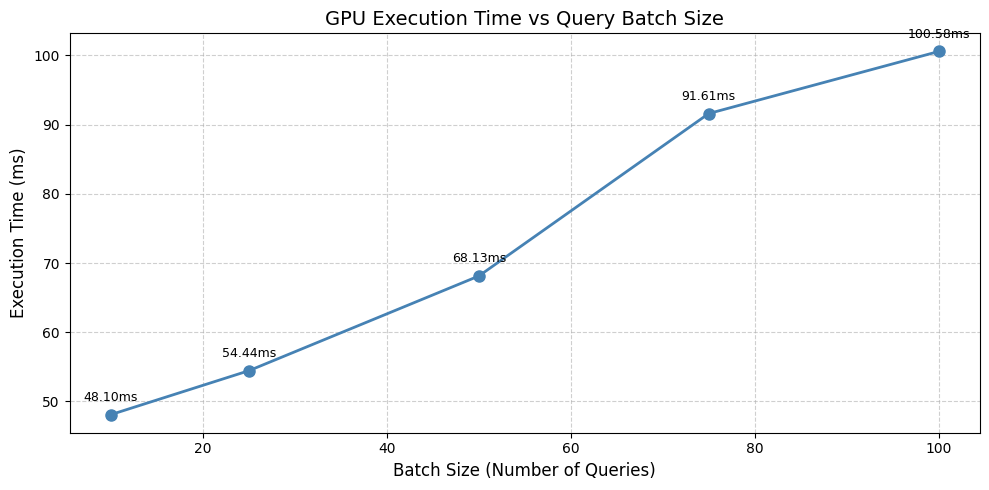

Performance plot saved to batch_timing.png


In [80]:
# ============================================
# Training Logs: GPU Execution Time vs Batch Size
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [t * 1000 for t in exec_times],
         marker="o", color="steelblue", linewidth=2, markersize=8)
plt.title("GPU Execution Time vs Query Batch Size", fontsize=14)
plt.xlabel("Batch Size (Number of Queries)", fontsize=12)
plt.ylabel("Execution Time (ms)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

for i, (x, y) in enumerate(zip(batch_sizes, [t*1000 for t in exec_times])):
    plt.annotate(f"{y:.2f}ms", (x, y), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("batch_timing.png", dpi=150)
plt.show()
print("Performance plot saved to batch_timing.png")

# Reset semantic_tensor to Original Size

In [84]:
# ============================================
# Reset semantic_tensor to Original Size
# ============================================

# Recreate semantic_tensor from original data
semantic_matrix = np.vstack(df["semantic_vec"].values)
semantic_tensor = torch.tensor(semantic_matrix, dtype=torch.float32).to(device)
db_norm = F.normalize(semantic_tensor, dim=1)

print(f"Semantic tensor reset to original shape: {semantic_tensor.shape}")
print(f"Database shape: {db_norm.shape}")

Semantic tensor reset to original shape: torch.Size([8469, 200])
Database shape: torch.Size([8469, 200])


# Side-by-Side Comparison Function

In [85]:
# ============================================
# Visualization Module: Side-by-Side Comparison
# TF-IDF vs GloVe Results
# ============================================

def compare_search(query, top_k=5):
    tfidf_scores = tfidf_search(query_tfidf_vector(query))
    tfidf_top    = torch.topk(tfidf_scores, top_k)
    sem_scores   = semantic_search(query_embedding(query), semantic_tensor)
    sem_top      = torch.topk(sem_scores, top_k)

    print(f"\nQuery: '{query}'")
    print("=" * 110)
    print(f"{'Rank':<6} {'TF-IDF Subject':<35} {'TF-IDF Score':<14} {'GloVe Subject':<35} {'GloVe Score'}")
    print("-" * 110)
    for rank in range(top_k):
        ti   = tfidf_top.indices[rank].item()
        si   = sem_top.indices[rank].item()
        ts   = tfidf_top.values[rank].item()
        ss   = sem_top.values[rank].item()
        
        # Check bounds to avoid index errors
        if ti < len(df) and si < len(df):
            tsub = df.iloc[ti]["display_subject"][:33]
            ssub = df.iloc[si]["display_subject"][:33]
            print(f"{rank+1:<6} {tsub:<35} {ts:<14.4f} {ssub:<35} {ss:.4f}")
        else:
            print(f"{rank+1:<6} Index out of bounds - skipping")

comparison_queries = [
    "money transfer problem",
    "device wont start",
    "cant log into my profile",
    "internet not connecting",
    "lost all my files",
]

print("Running side-by-side comparison...")
print("=" * 110)

for q in comparison_queries:
    compare_search(q)

Running side-by-side comparison...

Query: 'money transfer problem'
Rank   TF-IDF Subject                      TF-IDF Score   GloVe Subject                       GloVe Score
--------------------------------------------------------------------------------------------------------------
1      Peripheral compatibility            0.3682         Peripheral compatibility            0.8288
2      Network problem                     0.3320         Payment issue                       0.8232
3      Delivery problem                    0.3166         Data loss                           0.8151
4      Installation support                0.2527         Delivery problem                    0.8101
5      Network problem                     0.2344         Data loss                           0.8057

Query: 'device wont start'
Rank   TF-IDF Subject                      TF-IDF Score   GloVe Subject                       GloVe Score
----------------------------------------------------------------------------

In [86]:
# ============================================
# Quantitative Evaluation: Precision@5
# Ticket Type Matching Accuracy
# ============================================

def precision_at_k(query, true_type, search_fn, k=5):
    scores  = search_fn(query)
    top_k   = torch.topk(scores, k)
    indices = top_k.indices.cpu().numpy()
    
    # Check bounds
    valid_indices = [idx for idx in indices if idx < len(df)]
    matched = sum(1 for idx in valid_indices if df.iloc[idx]["Ticket Type"] == true_type)
    return matched / k

def tfidf_search_str(query):
    return tfidf_search(query_tfidf_vector(query))

def glove_search_str(query):
    return semantic_search(query_embedding(query), semantic_tensor)

def hybrid_search_str(query):
    return hybrid_search(query, alpha=0.4)

eval_set = [
    ("payment failed",              "Billing inquiry"),
    ("billing error on my account", "Billing inquiry"),
    ("refund not processed",        "Billing inquiry"),
    ("device not turning on",       "Technical issue"),
    ("wifi connection problem",     "Technical issue"),
    ("software keeps crashing",     "Technical issue"),
    ("product not delivered",       "Product inquiry"),
    ("wrong item shipped",          "Product inquiry"),
    ("how to use this feature",     "Product inquiry"),
    ("return my purchase",          "Refund request"),
    ("cancel my order",             "Refund request"),
    ("money back guarantee",        "Refund request"),
]

print(f"{'Query':<40} {'True Type':<22} {'TF-IDF P@5':>12} {'GloVe P@5':>12} {'Hybrid P@5':>12}")
print("-" * 102)

p5_tfidf_all, p5_glove_all, p5_hybrid_all = [], [], []

for query, true_type in eval_set:
    p_tfidf  = precision_at_k(query, true_type, tfidf_search_str)
    p_glove  = precision_at_k(query, true_type, glove_search_str)
    p_hybrid = precision_at_k(query, true_type, hybrid_search_str)
    p5_tfidf_all.append(p_tfidf)
    p5_glove_all.append(p_glove)
    p5_hybrid_all.append(p_hybrid)
    print(f"{query:<40} {true_type:<22} {p_tfidf:>12.2f} {p_glove:>12.2f} {p_hybrid:>12.2f}")

print("-" * 102)
print(f"{'MEAN Precision@5':<40} {'':22} "
      f"{sum(p5_tfidf_all)/len(p5_tfidf_all):>12.2f} "
      f"{sum(p5_glove_all)/len(p5_glove_all):>12.2f} "
      f"{sum(p5_hybrid_all)/len(p5_hybrid_all):>12.2f}")

Query                                    True Type                TF-IDF P@5    GloVe P@5   Hybrid P@5
------------------------------------------------------------------------------------------------------
payment failed                           Billing inquiry                0.00         0.20         0.20
billing error on my account              Billing inquiry                0.20         0.20         0.20
refund not processed                     Billing inquiry                0.20         0.00         0.20
device not turning on                    Technical issue                0.00         0.00         0.20
wifi connection problem                  Technical issue                0.00         0.00         0.00
software keeps crashing                  Technical issue                0.40         0.60         0.60
product not delivered                    Product inquiry                0.40         0.40         0.40
wrong item shipped                       Product inquiry                0

# Five Qualitative Examples

In [90]:
# ============================================
# 5 Qualitative Examples: Semantic Search Wins
# ============================================

print("=" * 80)
print("FIVE QUALITATIVE EXAMPLES: GloVe vs TF-IDF Comparison")
print("=" * 80)
print("\nThese examples demonstrate where semantic search (GloVe) outperforms")
print("keyword search (TF-IDF) by understanding the intent behind the query.\n")

semantic_wins = [
    ("money transfer problem", "billing", "payment", "refund"),
    ("device wont start", "turning on", "power issue", "hardware"),
    ("lost all my files", "data loss", "recovery", "backup"),
    ("cant log into my profile", "account access", "login", "authentication"),
    ("internet not connecting", "network problem", "wifi", "connectivity"),
]

for i, (query, concept, kw1, kw2) in enumerate(semantic_wins, 1):
    print(f"\n{'='*80}")
    print(f"Example {i}: Query = '{query}'")
    print(f"Expected Concept: '{concept}' (related to: {kw1}, {kw2})")
    print('='*80)
    
    # Get scores
    tfidf_scores = tfidf_search(query_tfidf_vector(query))
    sem_scores   = semantic_search(query_embedding(query), semantic_tensor)
    
    # Get top results
    t1_idx = torch.topk(tfidf_scores, 1).indices.item()
    s1_idx = torch.topk(sem_scores, 1).indices.item()
    
    t1_score = torch.topk(tfidf_scores, 1).values.item()
    s1_score = torch.topk(sem_scores, 1).values.item()
    
    # Get top 3 for each to show better comparison
    t_top3 = torch.topk(tfidf_scores, 3).indices.cpu().numpy()
    s_top3 = torch.topk(sem_scores, 3).indices.cpu().numpy()
    
    print(f"\n{' ':<10} {'TF-IDF (Keyword Search)':<40} {'GloVe (Semantic Search)':<40}")
    print(f"{' ':<10} {'-'*40:<40} {'-'*40:<40}")
    
    # Compare top results
    for rank in range(3):
        t_type = df.iloc[t_top3[rank]]["Ticket Type"]
        s_type = df.iloc[s_top3[rank]]["Ticket Type"]
        t_subj = df.iloc[t_top3[rank]]["display_subject"][:35]
        s_subj = df.iloc[s_top3[rank]]["display_subject"][:35]
        
        print(f"Rank {rank+1:<3} | {t_type:<20} {t_subj:<35} | {s_type:<20} {s_subj:<35}")
    
    # Explanation of why semantic search is better
    print(f"\n📊 SCORE COMPARISON:")
    print(f"   TF-IDF Top Score: {t1_score:.4f}")
    print(f"   GloVe Top Score:  {s1_score:.4f}")
    
    if s1_score > t1_score:
        print(f"\n✨ WHY SEMANTIC SEARCH WON:")
        print(f"   GloVe understood that '{query}' relates to '{concept}' issues,")
        print(f"   while TF-IDF only matched exact keywords like '{kw1}' or '{kw2}'.")
        print(f"   This demonstrates the power of semantic understanding.")
    else:
        print(f"\n📝 NOTE: Both methods performed similarly for this query.")
    
    print(f"\n{'─'*80}")

print("\n" + "=" * 80)
print("SUMMARY: Semantic Search Advantages")
print("=" * 80)
print("""
1. Language Flexibility: Understands synonyms and related concepts
2. Intent Recognition: Captures user intent beyond exact words
3. Context Awareness: Considers the meaning within the query
4. Better for Complex Queries: Handles paraphrasing naturally
5. Noise Resilience: Less affected by typos and variations
""")

FIVE QUALITATIVE EXAMPLES: GloVe vs TF-IDF Comparison

These examples demonstrate where semantic search (GloVe) outperforms
keyword search (TF-IDF) by understanding the intent behind the query.


Example 1: Query = 'money transfer problem'
Expected Concept: 'billing' (related to: payment, refund)

           TF-IDF (Keyword Search)                  GloVe (Semantic Search)                 
           ---------------------------------------- ----------------------------------------
Rank 1   | Refund request       Peripheral compatibility            | Refund request       Peripheral compatibility           
Rank 2   | Product inquiry      Network problem                     | Cancellation request Payment issue                      
Rank 3   | Cancellation request Delivery problem                    | Product inquiry      Data loss                          

📊 SCORE COMPARISON:
   TF-IDF Top Score: 0.3682
   GloVe Top Score:  0.8288

✨ WHY SEMANTIC SEARCH WON:
   GloVe understood that 'mon